# Phase 3 — Exploratory Data Analysis
Home Credit Default Risk Project

In [1]:
import sys
sys.path.append("../src")

from eda_utils import (
    get_column_lists,
    missing_values,
    bad_rate_summary,
    skewness_report,
    outlier_check,
    check_overlap,
    cardinality_report,
    sentinel_bad_rate,
    coverage_bad_rate,
    cardinal_freq,
)


In [2]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid")

RAW       = Path("../data/raw")
PROCESSED = Path("../data/processed")

con = duckdb.connect()

TABLES = [
    "application_train", "application_test",
    "bureau", "bureau_balance",
    "previous_application", "POS_CASH_balance",
    "installments_payments", "credit_card_balance",
]
for t in TABLES:
    con.execute(f"""
        CREATE OR REPLACE VIEW {t} AS
        SELECT * FROM '{(PROCESSED / f"{t}.parquet").as_posix()}'
    """)

col_desc = pd.read_csv(RAW / "HomeCredit_columns_description.csv",
                       encoding="latin-1", index_col=0)

print("Views:", con.execute("SHOW TABLES").df()["name"].tolist())

Views: ['POS_CASH_balance', 'application_test', 'application_train', 'bureau', 'bureau_balance', 'credit_card_balance', 'installments_payments', 'previous_application']


## Step 1 — Structural Sanity Checks

In [3]:
# Load train and test
df_train = con.execute("SELECT * FROM application_train").df()
df_test  = con.execute("SELECT * FROM application_test").df()

# 1a — Shapes
print(f"Train shape: {df_train.shape}")
print(f"Test shape:  {df_test.shape}")

Train shape: (307511, 122)
Test shape:  (48744, 121)


In [4]:
# 1b — TARGET exists in train but not test
target_columns = df_train.columns
test_columns   = df_test.columns

if "TARGET" in target_columns:
    print("✅ Train df has the TARGET column")
else:
    print("⚠️  Train df does NOT have the TARGET column")

if "TARGET" not in test_columns:
    print("✅ Test df does NOT have the TARGET column — correct")
else:
    print("⚠️  Test df has the TARGET column — investigate")

✅ Train df has the TARGET column
✅ Test df does NOT have the TARGET column — correct


In [5]:
# 1c — SK_ID_CURR uniqueness
if df_train["SK_ID_CURR"].nunique() == len(df_train["SK_ID_CURR"]):
    print("✅ No duplicate SK_ID_CURR in Train df")
else:
    print("⚠️  Duplicate SK_ID_CURR found in Train df")

if df_test["SK_ID_CURR"].nunique() == len(df_test["SK_ID_CURR"]):
    print("✅ No duplicate SK_ID_CURR in Test df")
else:
    print("⚠️  Duplicate SK_ID_CURR found in Test df")

✅ No duplicate SK_ID_CURR in Train df
✅ No duplicate SK_ID_CURR in Test df


In [6]:
# 1d — Train/test overlap check (uses check_overlap from eda_utils)
check_overlap(df_train, df_test, "SK_ID_CURR")

✅ No overlap found in 'SK_ID_CURR' between the two DataFrames


In [7]:
# 1e — Build reusable column lists (uses get_column_lists from eda_utils)
numeric_data, categorical_data, binary_data = get_column_lists(df_train)

print(f"Numeric:     {len(numeric_data)} columns")
print(f"Categorical: {len(categorical_data)} columns")
print(f"Binary FLAG: {len(binary_data)} columns")

Numeric:     80 columns
Categorical: 12 columns
Binary FLAG: 28 columns


## Step 2 — Target / Bad-Rate Analysis

In [8]:
# 2a — Credit risk summary (uses bad_rate_summary from eda_utils)
bad_rate_summary(df_train)

--- Credit Risk Summary ---
Total records:     307,511
Population PD:     8.07%
Total bads:        24,825
Total goods:       282,686
Good:Bad ratio:    11.4:1


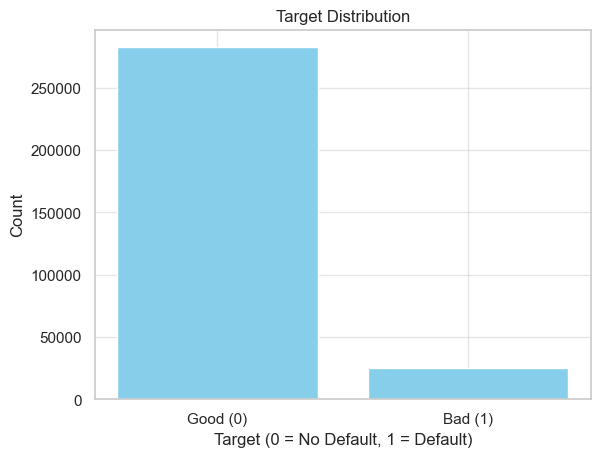

In [9]:
# 2b — Target distribution plot
counts = df_train["TARGET"].value_counts()

plt.bar(counts.index, counts.values, color="skyblue")
plt.xlabel("Target (0 = No Default, 1 = Default)")
plt.ylabel("Count")
plt.title("Target Distribution")
plt.xticks([0, 1], ["Good (0)", "Bad (1)"])
plt.show()

## Step 3 — Feature Typing, Cardinality & Sentinel Codes

In [10]:
# 3a — Categorical cardinality and value distributions
# (uses cardinality_report from eda_utils for the summary table)
cardinality_report(df_train, categorical_data)

Column                 Unique Top Value                       Top Count  Missing %
────────────────────────────────────────────────────────────────────────────────────────────────────
CODE_GENDER                 3 F                                  202448      0.00%
NAME_TYPE_SUITE             7 Unaccompanied                      248526      0.42%
NAME_INCOME_TYPE            8 Working                            158774      0.00%
NAME_EDUCATION_TYPE         5 Secondary / secondary special      218391      0.00%
NAME_FAMILY_STATUS          6 Married                            196432      0.00%
NAME_HOUSING_TYPE           6 House / apartment                  272868      0.00%
OCCUPATION_TYPE            18 Laborers                            55186     31.35%
WEEKDAY_APPR_PROCESS_START        7 TUESDAY                             53901      0.00%
ORGANIZATION_TYPE          58 Business Entity Type 3              67992      0.00%
FONDKAPREMONT_MODE          4 reg oper account                 

In [11]:
# 3b — Detailed value counts per categorical (sentinel hunting)
for i in categorical_data:
    if i in df_train.columns:
        print(f"\n{'─'*50}")
        print(f"{i} — {df_train[i].nunique()} unique values")
        print(df_train[i].value_counts())


──────────────────────────────────────────────────
CODE_GENDER — 3 unique values
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

──────────────────────────────────────────────────
NAME_TYPE_SUITE — 7 unique values
NAME_TYPE_SUITE
Unaccompanied      248526
Family              40149
Spouse, partner     11370
Children             3267
Other_B              1770
Other_A               866
Group of people       271
Name: count, dtype: int64

──────────────────────────────────────────────────
NAME_INCOME_TYPE — 8 unique values
NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64

──────────────────────────────────────────────────
NAME_EDUCATION_TYPE — 5 unique values
NAME_EDUCATION_TYPE
Secondary / secondary special    218391


In [12]:
# 3c — Sentinel bad rate checks for categorical sentinels
# ORGANIZATION_TYPE XNA
sentinel_bad_rate(df_train, "ORGANIZATION_TYPE", lambda x: x == "XNA")

--- Sentinel Bad Rate Check: ORGANIZATION_TYPE ---
Sentinel population bad rate:     5.40%
Non-sentinel population bad rate: 8.66%
Overall population bad rate:      8.07%
Difference:                       -3.26pp


In [13]:
# NAME_TYPE_SUITE — Other_A and Other_B rare category check
for category in ["Other_A", "Other_B"]:
    bad_rate = df_train[df_train["NAME_TYPE_SUITE"] == category]["TARGET"].mean() * 100
    count    = (df_train["NAME_TYPE_SUITE"] == category).sum()
    pct      = count / len(df_train) * 100
    print(f"{category}: bad rate = {bad_rate:.2f}%, count = {count:,} ({pct:.2f}% of population)")

Other_A: bad rate = 8.78%, count = 866 (0.28% of population)
Other_B: bad rate = 9.83%, count = 1,770 (0.58% of population)


In [14]:
# 3d — Numeric skewness report (uses skewness_report from eda_utils)
skewness_report(df_train, numeric_data)

SK_ID_CURR: 🟢 Fairly symmetrical: -0.001
count   307,511.000
mean    278,180.519
std     102,790.175
min     100,002.000
25%     189,145.500
50%     278,202.000
75%     367,142.500
max     456,255.000
Name: SK_ID_CURR, dtype: float64

TARGET: 🔴 Highly skewed RIGHT: 3.078
count   307,511.000
mean          0.081
std           0.272
min           0.000
25%           0.000
50%           0.000
75%           0.000
max           1.000
Name: TARGET, dtype: float64

CNT_CHILDREN: 🔴 Highly skewed RIGHT: 1.975
count   307,511.000
mean          0.417
std           0.722
min           0.000
25%           0.000
50%           0.000
75%           1.000
max          19.000
Name: CNT_CHILDREN, dtype: float64

AMT_INCOME_TOTAL: 🔴 Highly skewed RIGHT: 391.560
count       307,511.000
mean        168,797.919
std         237,123.146
min          25,650.000
25%         112,500.000
50%         147,150.000
75%         202,500.000
max     117,000,000.000
Name: AMT_INCOME_TOTAL, dtype: float64

AMT_CREDIT: 🔴 High

In [15]:
# 3e — Outlier check (uses outlier_check from eda_utils)
outlier_check(df_train, numeric_data)

Column                                            Min             Max     99th Pct     Skew
──────────────────────────────────────────────────────────────────────────────────────────
SK_ID_CURR                                 100,002.00      456,255.00   452,712.90   -0.001
TARGET                                           0.00            1.00         1.00    3.078
CNT_CHILDREN                                     0.00           19.00         3.00    1.975
AMT_INCOME_TOTAL                            25,650.00  117,000,000.00   472,500.00  391.560
AMT_CREDIT                                  45,000.00    4,050,000.00 1,854,000.00    1.235
AMT_ANNUITY                                  1,615.50      258,025.50    70,006.50    1.580
AMT_GOODS_PRICE                             40,500.00    4,050,000.00 1,800,000.00    1.349
REGION_POPULATION_RELATIVE                       0.00            0.07         0.07    1.488
DAYS_BIRTH                                 -25,229.00       -7,489.00    -8,263.0

In [16]:
# 3f — CNT_CHILDREN vs CNT_FAM_MEMBERS consistency check
print(df_train["CNT_CHILDREN"].value_counts().sort_index())
print(df_train["CNT_FAM_MEMBERS"].value_counts().sort_index())

inconsistent = df_train[df_train["CNT_CHILDREN"] > df_train["CNT_FAM_MEMBERS"]]
print(f"Inconsistent rows (CNT_CHILDREN > CNT_FAM_MEMBERS): {len(inconsistent)}")

CNT_CHILDREN
0     215371
1      61119
2      26749
3       3717
4        429
5         84
6         21
7          7
8          2
9          2
10         2
11         1
12         2
14         3
19         2
Name: count, dtype: int64
CNT_FAM_MEMBERS
1.000      67847
2.000     158357
3.000      52601
4.000      24697
5.000       3478
6.000        408
7.000         81
8.000         20
9.000          6
10.000         3
11.000         1
12.000         2
13.000         1
14.000         2
15.000         1
16.000         2
20.000         2
Name: count, dtype: int64
Inconsistent rows (CNT_CHILDREN > CNT_FAM_MEMBERS): 0


In [17]:
# 3g — DAYS_EMPLOYED sentinel check (uses sentinel_bad_rate from eda_utils)
print(df_train["DAYS_EMPLOYED"].describe())
print(f"\nRows with sentinel (365243): {(df_train['DAYS_EMPLOYED'] == 365243).sum():,}")
print(f"% of data: {(df_train['DAYS_EMPLOYED'] == 365243).mean() * 100:.2f}%")

# Overlap with ORGANIZATION_TYPE XNA
overlap_sentinel = df_train[
    (df_train["DAYS_EMPLOYED"] == 365243) &
    (df_train["ORGANIZATION_TYPE"] == "XNA")
]["SK_ID_CURR"].nunique()
print(f"Overlap with ORGANIZATION_TYPE XNA: {overlap_sentinel:,}")

# Bad rate check
sentinel_bad_rate(df_train, "DAYS_EMPLOYED", lambda x: x == 365243)

count   307,511.000
mean     63,815.046
std     141,275.767
min     -17,912.000
25%      -2,760.000
50%      -1,213.000
75%        -289.000
max     365,243.000
Name: DAYS_EMPLOYED, dtype: float64

Rows with sentinel (365243): 55,374
% of data: 18.01%
Overlap with ORGANIZATION_TYPE XNA: 55,374
--- Sentinel Bad Rate Check: DAYS_EMPLOYED ---
Sentinel population bad rate:     5.40%
Non-sentinel population bad rate: 8.66%
Overall population bad rate:      8.07%
Difference:                       -3.26pp


In [18]:
# 3h — OWN_CAR_AGE sentinel check (uses sentinel_bad_rate from eda_utils)
print(df_train[df_train["OWN_CAR_AGE"] >= 60]["OWN_CAR_AGE"].value_counts().sort_index())
print(f"99th percentile: {df_train['OWN_CAR_AGE'].quantile(0.99)}")
print(f"Total rows with OWN_CAR_AGE = 64: {(df_train['OWN_CAR_AGE'] == 64).sum():,}")
print(f"% of cars with age recorded: {df_train['OWN_CAR_AGE'].notna().mean() * 100:.2f}%")

sentinel_bad_rate(df_train, "OWN_CAR_AGE", lambda x: x == 64)

OWN_CAR_AGE
63.000       2
64.000    2443
65.000     891
69.000       1
91.000       2
Name: count, dtype: int64
99th percentile: 64.0
Total rows with OWN_CAR_AGE = 64: 2,443
% of cars with age recorded: 34.01%
--- Sentinel Bad Rate Check: OWN_CAR_AGE ---
Sentinel population bad rate:     8.60%
Non-sentinel population bad rate: 7.21%
Overall population bad rate:      8.07%
Difference:                       +1.38pp


In [19]:
# 3i — Normalized features verification (EXT_SOURCE + building stats)
normalized_cols = [
    col for col in df_train.columns
    if (col in ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
    or col.endswith("_AVG") or col.endswith("_MEDI")
    or col.endswith("_MODE"))
    and df_train[col].dtype in ["float64", "int64"]
]
for col in normalized_cols:
    print(f"{col:<40} min={df_train[col].min():.3f}  max={df_train[col].max():.3f}")

EXT_SOURCE_1                             min=0.015  max=0.963
EXT_SOURCE_2                             min=0.000  max=0.855
EXT_SOURCE_3                             min=0.001  max=0.896
APARTMENTS_AVG                           min=0.000  max=1.000
BASEMENTAREA_AVG                         min=0.000  max=1.000
YEARS_BEGINEXPLUATATION_AVG              min=0.000  max=1.000
YEARS_BUILD_AVG                          min=0.000  max=1.000
COMMONAREA_AVG                           min=0.000  max=1.000
ELEVATORS_AVG                            min=0.000  max=1.000
ENTRANCES_AVG                            min=0.000  max=1.000
FLOORSMAX_AVG                            min=0.000  max=1.000
FLOORSMIN_AVG                            min=0.000  max=1.000
LANDAREA_AVG                             min=0.000  max=1.000
LIVINGAPARTMENTS_AVG                     min=0.000  max=1.000
LIVINGAREA_AVG                           min=0.000  max=1.000
NONLIVINGAPARTMENTS_AVG                  min=0.000  max=1.000
NONLIVIN

## Step 4 — Missing Value Rate

In [20]:
# 4a — Missing value rate for application_train (uses missing_values from eda_utils)
print("=== application_train ===")
missing_values(df_train)

=== application_train ===
🟢 Percent missing:
COMMONAREA_AVG             69.870
COMMONAREA_MODE            69.870
COMMONAREA_MEDI            69.870
NONLIVINGAPARTMENTS_MEDI   69.430
NONLIVINGAPARTMENTS_MODE   69.430
                            ...  
OBS_60_CNT_SOCIAL_CIRCLE    0.330
DEF_30_CNT_SOCIAL_CIRCLE    0.330
OBS_30_CNT_SOCIAL_CIRCLE    0.330
EXT_SOURCE_2                0.210
AMT_GOODS_PRICE             0.090
Length: 64, dtype: float64

🟢 Number missing:
COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
COMMONAREA_MEDI             214865
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_MODE    213514
                             ...  
EXT_SOURCE_2                   660
AMT_GOODS_PRICE                278
AMT_ANNUITY                     12
CNT_FAM_MEMBERS                  2
DAYS_LAST_PHONE_CHANGE           1
Length: 67, dtype: int64


In [21]:
# 4b — EXT_SOURCE missing analysis
df_EXT_SOURCE_123 = df_train[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]]
missing_values(df_EXT_SOURCE_123)

🟢 Percent missing:
EXT_SOURCE_1   56.380
EXT_SOURCE_3   19.830
EXT_SOURCE_2    0.210
dtype: float64

🟢 Number missing:
EXT_SOURCE_1    173378
EXT_SOURCE_3     60965
EXT_SOURCE_2       660
dtype: int64


In [22]:
# 4c — EXT_SOURCE informative missingness check (uses sentinel_bad_rate from eda_utils)
for source in ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]:
    sentinel_bad_rate(df_train, source, lambda x: x.isna())
    print()

--- Sentinel Bad Rate Check: EXT_SOURCE_1 ---
Sentinel population bad rate:     8.52%
Non-sentinel population bad rate: 7.50%
Overall population bad rate:      8.07%
Difference:                       +1.02pp

--- Sentinel Bad Rate Check: EXT_SOURCE_2 ---
Sentinel population bad rate:     7.88%
Non-sentinel population bad rate: 8.07%
Overall population bad rate:      8.07%
Difference:                       -0.19pp

--- Sentinel Bad Rate Check: EXT_SOURCE_3 ---
Sentinel population bad rate:     9.31%
Non-sentinel population bad rate: 7.77%
Overall population bad rate:      8.07%
Difference:                       +1.55pp



## Bureau Table — Missing Value Rate

In [23]:
# Load bureau and run missing values
df_bureau = con.execute("SELECT * FROM bureau").df()
print(f"Bureau shape: {df_bureau.shape}")
missing_values(df_bureau)

Bureau shape: (1716428, 17)
🟢 Percent missing:
AMT_ANNUITY              71.470
AMT_CREDIT_MAX_OVERDUE   65.510
DAYS_ENDDATE_FACT        36.920
AMT_CREDIT_SUM_LIMIT     34.480
AMT_CREDIT_SUM_DEBT      15.010
DAYS_CREDIT_ENDDATE       6.150
dtype: float64

🟢 Number missing:
AMT_ANNUITY               1226791
AMT_CREDIT_MAX_OVERDUE    1124488
DAYS_ENDDATE_FACT          633653
AMT_CREDIT_SUM_LIMIT       591780
AMT_CREDIT_SUM_DEBT        257669
DAYS_CREDIT_ENDDATE        105553
AMT_CREDIT_SUM                 13
dtype: int64


In [24]:
# Bureau table contains records for all clients Home Credit has ever had data on, I need just the one from my Train dataset
df_bureau = con.execute("""
    SELECT * FROM bureau
    WHERE SK_ID_CURR in (SELECT SK_ID_CURR FROM application_train)
""").df()

print(f"Bureau shape: {df_bureau.shape}\n")
missing_values(df_bureau)
print(f"Unique applicants in bureau: {df_bureau['SK_ID_CURR'].nunique():,}\n")
print(f"Total train applicants:      {df_train['SK_ID_CURR'].nunique():,}\n")
coverage = df_bureau['SK_ID_CURR'].nunique() / df_train['SK_ID_CURR'].nunique() * 100
print(f"Coverage:                    {coverage:.1f}%\n")
print(f"\nRows per applicant:")
print(df_bureau.groupby('SK_ID_CURR').size().describe())

Bureau shape: (1465325, 17)

🟢 Percent missing:
AMT_ANNUITY              77.120
AMT_CREDIT_MAX_OVERDUE   64.730
DAYS_ENDDATE_FACT        37.170
AMT_CREDIT_SUM_LIMIT     33.420
AMT_CREDIT_SUM_DEBT      15.220
DAYS_CREDIT_ENDDATE       6.080
dtype: float64

🟢 Number missing:
AMT_ANNUITY               1130013
AMT_CREDIT_MAX_OVERDUE     948545
DAYS_ENDDATE_FACT          544673
AMT_CREDIT_SUM_LIMIT       489670
AMT_CREDIT_SUM_DEBT        223094
DAYS_CREDIT_ENDDATE         89098
AMT_CREDIT_SUM                  3
dtype: int64
Unique applicants in bureau: 263,491

Total train applicants:      307,511

Coverage:                    85.7%


Rows per applicant:
count   263,491.000
mean          5.561
std           4.378
min           1.000
25%           2.000
50%           4.000
75%           8.000
max         116.000
dtype: float64


In [25]:
coverage_bad_rate(df_train, df_bureau, "SK_ID_CURR")

--- Coverage Bad Rate Check: SK_ID_CURR ---
Applicants with records:    263,491 (85.7%)
Thin-file (no records):     44,020 (14.3%)
Bad rate — has records:     7.73%
Bad rate — thin file:       10.12%
Bad rate — population:      8.07%
Difference:                 +2.39pp


In [26]:
print(df_bureau.groupby("SK_ID_CURR").size().sort_values(ascending=False).head(10))

SK_ID_CURR
120860    116
169704     94
251643     61
295809     59
129843     58
177014     56
280155     55
218175     55
281455     54
430261     54
dtype: int64


In [27]:
# Creating the list of columns for 3 different type
numeric_bureau, categorical_bureau, binary_bureau = get_column_lists(df_bureau)

print(f"\nNumeric: {numeric_bureau}")
print(f"Numeric: {len(numeric_bureau)} columns")

print(f"\nCategorical: {categorical_bureau}")
print(f"Categorical: {len(categorical_bureau)} columns")

print(f"\nBinary: {binary_bureau}")
print(f"Binary: {len(binary_bureau)} columns")


Numeric: ['SK_ID_CURR', 'SK_ID_BUREAU', 'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE', 'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT', 'AMT_CREDIT_SUM_OVERDUE', 'DAYS_CREDIT_UPDATE', 'AMT_ANNUITY']
Numeric: 14 columns

Categorical: ['CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'CREDIT_TYPE']
Categorical: 3 columns

Binary: []
Binary: 0 columns


In [28]:
cardinality_report(df_bureau, categorical_bureau)


Column                 Unique Top Value                       Top Count  Missing %
────────────────────────────────────────────────────────────────────────────────────────────────────
CREDIT_ACTIVE               4 Closed                             917733      0.00%
CREDIT_CURRENCY             4 currency 1                        1464094      0.00%
CREDIT_TYPE                15 Consumer credit                   1069610      0.00%


In [31]:
cardinal_freq(df_bureau,categorical_bureau)

CREDIT_ACTIVE
Closed      917733
Active      541919
Sold          5653
Bad debt        20
Name: count, dtype: int64

CREDIT_CURRENCY
currency 1    1464094
currency 2       1072
currency 3        150
currency 4          9
Name: count, dtype: int64

CREDIT_TYPE
Consumer credit                                 1069610
Credit card                                      343853
Car loan                                          23757
Mortgage                                          15607
Microloan                                          9005
Loan for business development                      1721
Another type of loan                                854
Unknown type of loan                                472
Loan for working capital replenishment              377
Cash loan (non-earmarked)                            23
Real estate loan                                     23
Loan for the purchase of equipment                   17
Loan for purchase of shares (margin lending)          4
Interbank cr

In [39]:
print(bureau_with_target.groupby("CREDIT_ACTIVE")["TARGET"].mean().sort_values(ascending=False) * 100)

CREDIT_ACTIVE
Bad debt   20.000
Sold       10.101
Active      9.288
Closed      6.931
Name: TARGET, dtype: float64


In [40]:
print(bureau_with_target.groupby("CREDIT_TYPE")["TARGET"].mean().sort_values(ascending=False) * 100)

CREDIT_TYPE
Loan for the purchase of equipment             23.529
Microloan                                      20.644
Loan for working capital replenishment         12.732
Credit card                                     8.801
Consumer credit                                 7.484
Another type of loan                            7.143
Loan for business development                   6.159
Unknown type of loan                            6.144
Car loan                                        5.573
Mortgage                                        4.998
Cash loan (non-earmarked)                       4.348
Interbank credit                                0.000
Loan for purchase of shares (margin lending)    0.000
Mobile operator loan                            0.000
Real estate loan                                0.000
Name: TARGET, dtype: float64


In [32]:
skewness_report(df_bureau, numeric_bureau)

SK_ID_CURR: 🟢 Fairly symmetrical: -0.000
count   1,465,325.000
mean      278,328.538
std       102,919.334
min       100,002.000
25%       188,970.000
50%       278,289.000
75%       367,494.000
max       456,255.000
Name: SK_ID_CURR, dtype: float64

SK_ID_BUREAU: 🟢 Fairly symmetrical: 0.100
count   1,465,325.000
mean    5,890,327.739
std       537,827.071
min     5,000,000.000
25%     5,416,944.000
50%     5,856,021.000
75%     6,363,543.000
max     6,843,457.000
Name: SK_ID_BUREAU, dtype: float64

DAYS_CREDIT: 🟡 Moderately skewed LEFT: -0.578
count   1,465,325.000
mean       -1,143.600
std           800.020
min        -2,922.000
25%        -1,671.000
50%          -985.000
75%          -470.000
max             0.000
Name: DAYS_CREDIT, dtype: float64

CREDIT_DAY_OVERDUE: 🔴 Highly skewed RIGHT: 53.571
count   1,465,325.000
mean            0.889
std            38.247
min             0.000
25%             0.000
50%             0.000
75%             0.000
max         2,792.000
Name: CREDIT

In [35]:
# AMT_CREDIT_SUM_DEBT min = -4,705,600 -> Negative debt is impossible in theory
print(f"Negative debt rows: {(df_bureau['AMT_CREDIT_SUM_DEBT'] < 0).sum():,}")

# AMT_CREDIT_SUM_LIMIT min = -586,406 Same issue — negative credit limit is impossible.
print(f"Negative limit rows: {(df_bureau['AMT_CREDIT_SUM_LIMIT'] <0 ).sum():,}")

# DAYS_CREDIT_UPDATE max = 372 Positive value means the update happened after the application date — suspicious.
print(f"Rows with future update: {(df_bureau['DAYS_CREDIT_UPDATE'] > 0).sum():,}")

print(f"Ever overdue: {(df_bureau['CREDIT_DAY_OVERDUE'] > 0).sum():,}")
print(f"Ever prolonged: {(df_bureau['CNT_CREDIT_PROLONG'] > 0).sum():,}")

Negative debt rows: 8,418
Negative limit rows: 351
Rows with future update: 17
Ever overdue: 3,706
Ever prolonged: 8,820


In [37]:
# CREDIT_DAY_OVERDUE — 3,706 ever overdue Only 0.25% of bureau credits are currently overdue — but these are extremely high-risk signals.
bureau_with_target = df_bureau.merge(
    df_train[["SK_ID_CURR", "TARGET"]],
    on="SK_ID_CURR",
    how="left"
)

overdue_bad = bureau_with_target[bureau_with_target["CREDIT_DAY_OVERDUE"] > 0]["TARGET"].mean() * 100
non_overdue_bad = bureau_with_target[bureau_with_target["CREDIT_DAY_OVERDUE"] == 0]["TARGET"].mean() * 100

print(f"Bad rate — currently overdue:     {overdue_bad:.2f}%")
print(f"Bad rate — not overdue:           {non_overdue_bad:.2f}%")

Bad rate — currently overdue:     18.21%
Bad rate — not overdue:           7.79%


In [38]:
# CNT_CREDIT_PROLONG 8,820 ever prolonged 0.60% of credits were prolonged at least once.
prolonged_bad = bureau_with_target[bureau_with_target["CNT_CREDIT_PROLONG"] > 0]["TARGET"].mean() * 100
non_prolonged_bad = bureau_with_target[bureau_with_target["CNT_CREDIT_PROLONG"] == 0]["TARGET"].mean() * 100

print(f"Bad rate — ever prolonged:        {prolonged_bad:.2f}%")
print(f"Bad rate — never prolonged:       {non_prolonged_bad:.2f}%")

Bad rate — ever prolonged:        8.73%
Bad rate — never prolonged:       7.81%
